In [1]:
# -*- coding: utf-8 -*-
"""
多模式多波长光场调制系统 - 主程序
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import time



In [2]:
from config import Config

# 设置随机种子，确保结果可重现
torch.manual_seed(42)
np.random.seed(42)

# 创建配置
config = Config(
    # 基本参数
    num_modes=3,                                # 模式数量
    wavelengths=np.array([450e-9, 550e-9, 650e-9]),  # 波长列表(m)
    
    # 空间参数
    field_size=50,                              # 场大小(像素)
    layer_size=200,                             # 层大小(像素)
    focus_radius=5,                             # 焦点半径(像素)
    detectsize=15,                              # 检测区域大小(像素)
    
    # 物理参数
    z_layers=40e-6,                             # 层间距离(m)
    z_prop=300e-6,                              # 传播距离(m)
    z_step=20e-6,                               # 传播步长(m)
    pixel_size=1e-6,                            # 像素大小(m)
    
    # 波长偏移 - 沿水平方向(X轴)
    offsets=[
        (-60, 0),  # 450nm
        (0, 0),    # 550nm
        (60, 0)    # 650nm
    ],
    
    # 模式偏移 - 沿垂直方向(Y轴)
    mode_offsets=[
        (0, -60),  # 模式0
        (0, 0),    # 模式1
        (0, 60)    # 模式2
    ],
    
    # 训练参数
    learning_rate=0.01,                         # 学习率
    lr_decay=0.99,                              # 学习率衰减
    epochs=400,                                 # 训练轮数
    batch_size=3,                               # 批量大小
    
    # 保存参数
    save_dir="./results_multi_mode_multi_wl/",  # 保存目录
    flag_savemat=True                           # 是否保存.mat文件
)


使用配置中的基本偏移，为每个模式添加正交偏移...
生成的组合偏移: [[(-60, -60), (0, -60), (60, -60)], [(-60, 0), (0, 0), (60, 0)], [(-60, 60), (0, 60), (60, 60)]]
初始化多模式多波长数据生成器:
  - 模式数量: 3
  - 波长数量: 3
  - 波长列表: ['450nm', '550nm', '650nm']
  - 偏移设置: [[(-60, -60), (0, -60), (60, -60)], [(-60, 0), (0, 0), (60, 0)], [(-60, 60), (0, 60), (60, 60)]]
初始化多模式多波长数据生成器:
  - 模式数量: 3
  - 波长数量: 3
  - 波长列表: ['450nm', '550nm', '650nm']
  - 偏移设置: [[(-60, -60), (0, -60), (60, -60)], [(-60, 0), (0, 0), (60, 0)], [(-60, 60), (0, 60), (60, 60)]]
标签位置图已保存至: label_positions.png


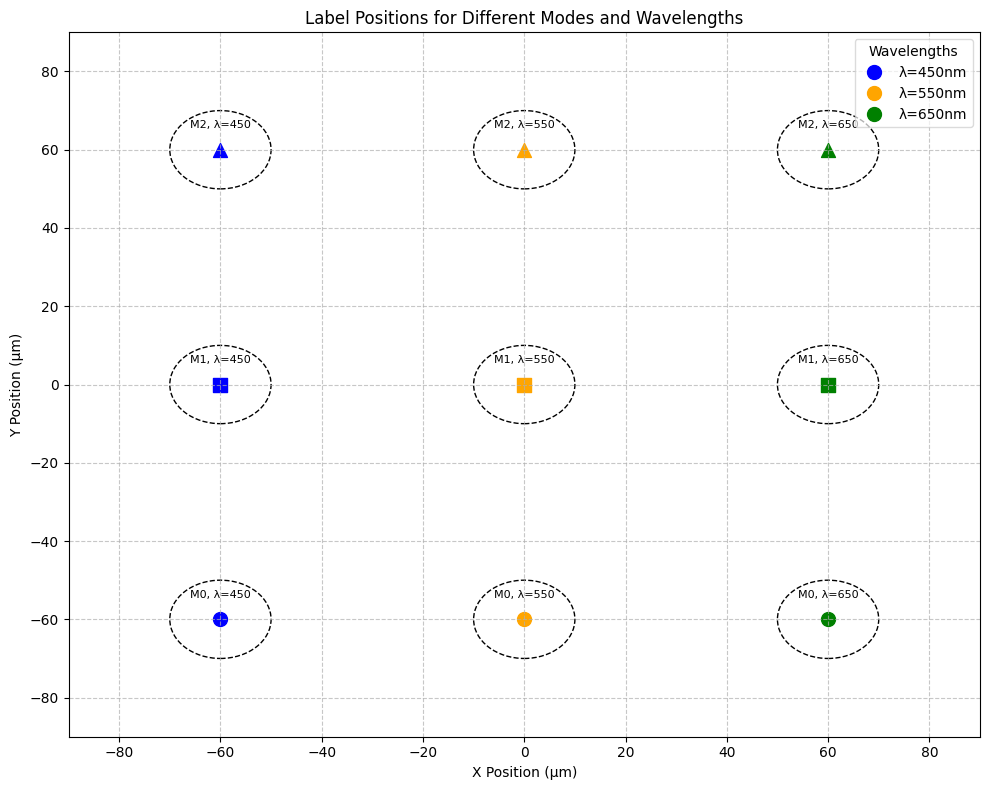

原始数据形状: (50, 50, 55)
选择后的数据形状: (3, 50, 50)
模式 1 振幅范围: 0.0000 - 0.1029
模式 2 振幅范围: 0.0000 - 0.0886
模式 3 振幅范围: 0.0000 - 0.0886
已加载 3 个模式


/home/shiyue/ODNN_MULTIWAVE/ODNN_WAVE/data_generator.py:430: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  plt.tight_layout()
/home/shiyue/ODNN_MULTIWAVE/ODNN_WAVE/data_generator.py:430: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from current font.
  plt.tight_layout()
/home/shiyue/ODNN_MULTIWAVE/ODNN_WAVE/data_generator.py:430: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from current font.
  plt.tight_layout()
/home/shiyue/ODNN_MULTIWAVE/ODNN_WAVE/data_generator.py:430: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from current font.
  plt.tight_layout()
/home/shiyue/ODNN_MULTIWAVE/ODNN_WAVE/data_generator.py:430: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from current font.
  plt.tight_layout()
/home/shiyue/ODNN_MULTIWAVE/ODNN_WAVE/data_generator.py:430: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from current font.
  plt.tight_layout(

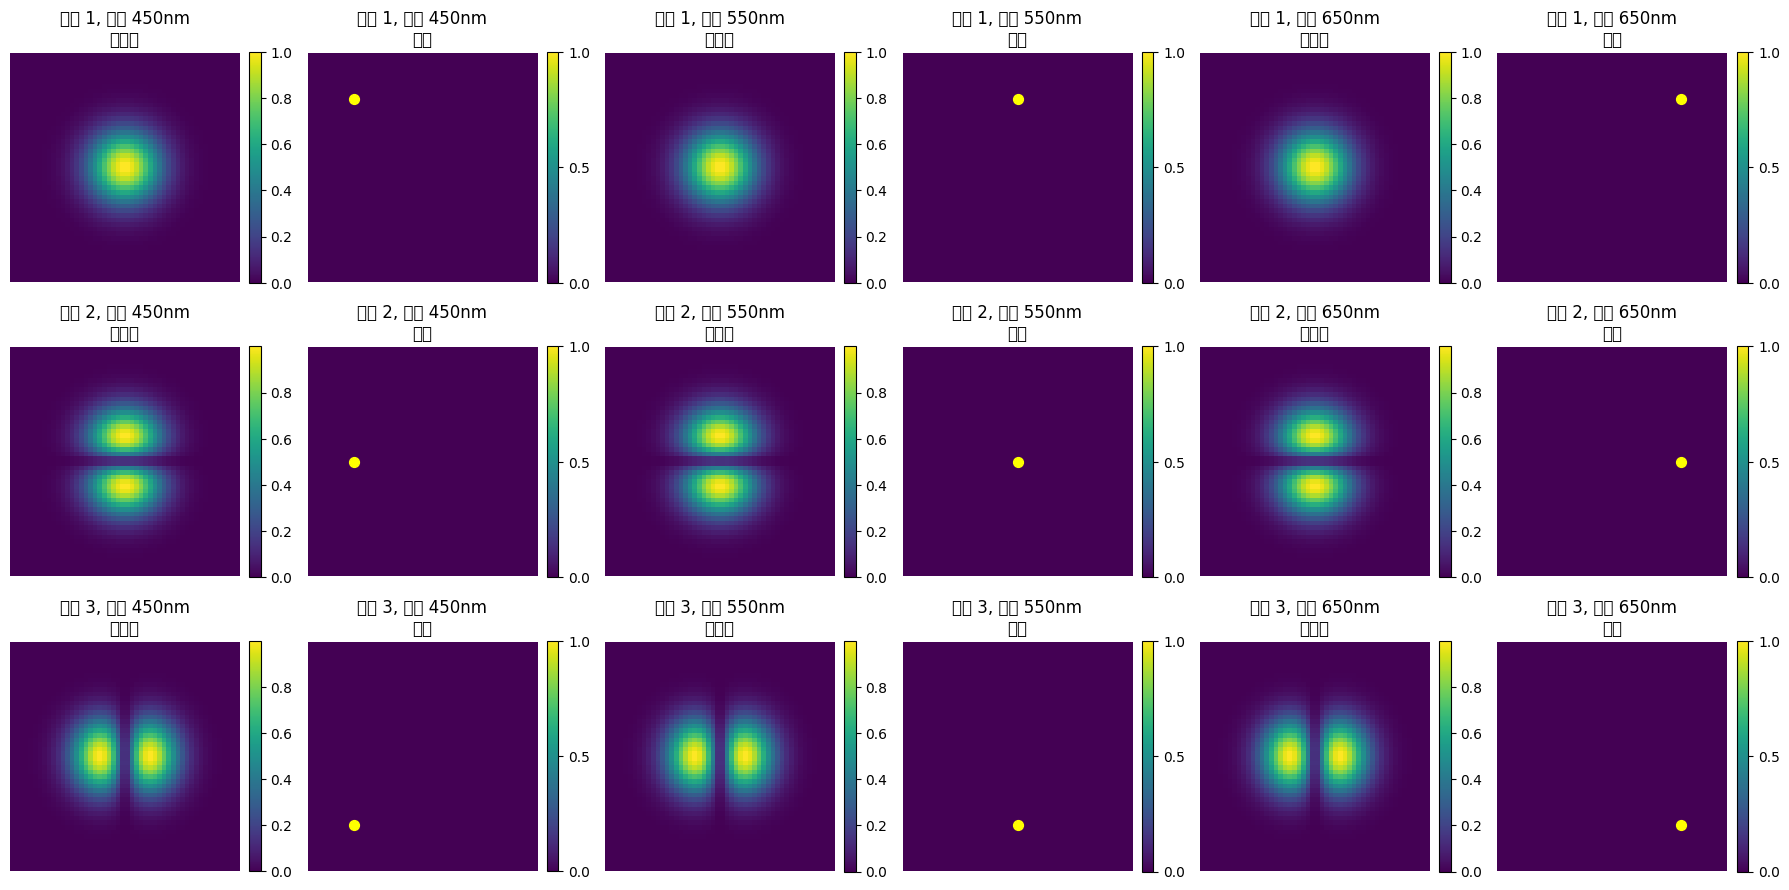

In [3]:
from data_generator import MultiModeMultiWavelengthDataGenerator
# 创建数据生成器
data_generator = MultiModeMultiWavelengthDataGenerator(config)


# 创建数据生成器
data_generator = MultiModeMultiWavelengthDataGenerator(config)

# 可视化标签位置
fig, ax = data_generator.visualize_label_positions(save_path='label_positions.png')
plt.show()

# 生成数据并可视化
data_generator.visualize_data(save_path='data_visualization.png')

# 创建数据加载器
dataloader = data_generator.create_dataloader(num_samples=30, batch_size=6)

In [4]:
from trainer import Trainer
from model import MultiModeMultiWavelengthModel
from label_utils import create_evaluation_regions_mode_wavelength

print("创建评估区域...")
# 创建评估区域 - 现在返回掩码数组列表
evaluation_regions = create_evaluation_regions_mode_wavelength(
    config.layer_size, 
    config.layer_size, 
    config.focus_radius, 
    detectsize=config.detectsize
)

print(f"评估区域数量: {len(evaluation_regions)}")
print(f"每个区域形状: {evaluation_regions[0].shape if evaluation_regions else 'None'}")

# 验证评估区域
for i, region in enumerate(evaluation_regions[:3]):  # 只显示前3个
    print(f"区域 {i}: 非零元素数量 = {np.sum(region > 0)}")

# 创建训练器
print("创建训练器...")
trainer = Trainer(config, data_generator, MultiModeMultiWavelengthModel, evaluation_regions=evaluation_regions)

# 定义要训练的层数选项
num_layer_options = [1, 2, 3]

print("训练器创建成功！")


创建评估区域...
评估区域数量: 9
每个区域形状: (200, 200)
区域 0: 非零元素数量 = 709
区域 1: 非零元素数量 = 709
区域 2: 非零元素数量 = 709
创建训练器...
使用外部提供的评估区域: 9个区域
训练器创建成功！


In [ ]:

# 训练多个模型
print(f"开始训练 {len(num_layer_options)} 个不同层数的模型...")
results = trainer.train_multiple_models(num_layer_options)
# end_time = time.time()
# print(f"训练完成，耗时: {end_time - start_time:.2f} 秒")


开始训练 3 个不同层数的模型...


ValueError: too many values to unpack (expected 4)

In [ ]:
# 可视化训练损失
print("可视化训练损失...")
plt.figure(figsize=(10, 6))
for i, num_layers in enumerate(num_layer_options):
    plt.plot(results['losses'][i], label=f'{num_layers} 层')
plt.xlabel('训练轮次')
plt.ylabel('损失值')
plt.title('不同层数模型的训练损失')
plt.legend()
plt.grid(True)
plt.savefig(f"{config.save_dir}/training_losses.png", dpi=300)
plt.show()


In [ ]:
# Improved energy distribution visualization
print("Visualizing energy distribution...")
for i, num_layers in enumerate(num_layer_options):
    # Get weights for current layer model
    current_weights = results['weights_pred'][i]  # Shape should be (num_wavelengths, num_modes, num_regions)
    
    # 1. Visualize by wavelength
    fig, axes = plt.subplots(1, len(config.wavelengths), figsize=(5*len(config.wavelengths), 4))
    fig.suptitle(f'Energy Distribution by Wavelength ({num_layers} Layers)', fontsize=16)
    
    for wl_idx, wavelength in enumerate(config.wavelengths):
        ax = axes[wl_idx] if len(config.wavelengths) > 1 else axes
        
        # Extract weights for current wavelength
        wl_weights = current_weights[wl_idx]  # Shape is (num_modes, num_regions)
        
        # Create heatmap
        im = ax.imshow(wl_weights, cmap='viridis', aspect='auto')
        ax.set_title(f'Wavelength {wavelength*1e9:.0f} nm')
        ax.set_xlabel('Detection Region')
        ax.set_ylabel('Mode')
        ax.set_yticks(range(config.num_modes))
        ax.set_yticklabels([f'Mode {m+1}' for m in range(config.num_modes)])
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/energy_by_wavelength_{num_layers}_layers.png", dpi=300)
    plt.show()
    
    # 2. Visualize by mode
    fig, axes = plt.subplots(config.num_modes, 1, figsize=(8, 3*config.num_modes))
    fig.suptitle(f'Energy Distribution by Mode ({num_layers} Layers)', fontsize=16)
    
    for mode_idx in range(config.num_modes):
        ax = axes[mode_idx] if config.num_modes > 1 else axes
        
        # Extract weights for current mode across all wavelengths
        mode_weights = np.array([current_weights[wl_idx][mode_idx] for wl_idx in range(len(config.wavelengths))])
        
        # Create heatmap
        im = ax.imshow(mode_weights, cmap='plasma', aspect='auto')
        ax.set_title(f'Mode {mode_idx+1}')
        ax.set_xlabel('Detection Region')
        ax.set_ylabel('Wavelength')
        ax.set_yticks(range(len(config.wavelengths)))
        ax.set_yticklabels([f'{wl*1e9:.0f} nm' for wl in config.wavelengths])
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/energy_by_mode_{num_layers}_layers.png", dpi=300)
    plt.show()
    
    # 3. Calculate and visualize cross-talk
    cross_talk = np.zeros((config.num_modes, len(config.wavelengths)))
    for mode_idx in range(config.num_modes):
        for wl_idx in range(len(config.wavelengths)):
            # Calculate energy ratio between target region and non-target regions
            target_region = 3 * mode_idx + wl_idx  # Assuming target region index is 3*mode_idx + wl_idx
            target_energy = current_weights[wl_idx][mode_idx][target_region]
            total_energy = np.sum(current_weights[wl_idx][mode_idx])
            if total_energy > 0:
                cross_talk[mode_idx, wl_idx] = 1.0 - (target_energy / total_energy)
    
    # Visualize cross-talk
    plt.figure(figsize=(8, 6))
    plt.imshow(cross_talk, cmap='coolwarm', aspect='auto')
    plt.colorbar(label='Cross-talk Ratio')
    plt.title(f'Mode-Wavelength Cross-talk ({num_layers} Layers)')
    plt.xlabel('Wavelength')
    plt.ylabel('Mode')
    plt.xticks(range(len(config.wavelengths)), [f'{wl*1e9:.0f} nm' for wl in config.wavelengths])
    plt.yticks(range(config.num_modes), [f'Mode {m+1}' for m in range(config.num_modes)])
    
    # Display values in each cell
    for i in range(config.num_modes):
        for j in range(len(config.wavelengths)):
            plt.text(j, i, f'{cross_talk[i, j]:.2f}', 
                     ha='center', va='center', color='white' if cross_talk[i, j] > 0.5 else 'black')
    
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/cross_talk_{num_layers}_layers.png", dpi=300)
    plt.show()


In [ ]:
# Improved energy distribution visualization - Individual plots for each wavelength-mode combination
print("Visualizing energy distribution...")
for i, num_layers in enumerate(num_layer_options):
    # Get weights for current layer model
    current_weights = results['weights_pred'][i]  # Shape should be (num_wavelengths, num_modes, num_regions)
    
    # Create individual plots for each wavelength-mode combination
    for wl_idx, wavelength in enumerate(config.wavelengths):
        for mode_idx in range(config.num_modes):
            # Extract weights for current wavelength and mode
            mode_wl_weights = current_weights[wl_idx][mode_idx]  # Shape is (num_regions,)
            
            # Reshape to 2D grid for better visualization (assuming 3x3 regions)
            grid_size = int(np.sqrt(len(mode_wl_weights)))
            if grid_size * grid_size == len(mode_wl_weights):
                weights_2d = mode_wl_weights.reshape(grid_size, grid_size)
            else:
                # If not perfect square, use 1D bar plot
                weights_2d = None
            
            # Create figure
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
            fig.suptitle(f'Energy Distribution: Wavelength {wavelength*1e9:.0f} nm, Mode {mode_idx+1} ({num_layers} Layers)', 
                        fontsize=14, fontweight='bold')
            
            # Plot 1: 2D heatmap (if possible)
            if weights_2d is not None:
                im1 = ax1.imshow(weights_2d, cmap='viridis', aspect='equal')
                ax1.set_title('2D Energy Map')
                ax1.set_xlabel('X Position')
                ax1.set_ylabel('Y Position')
                
                # Add region numbers as text
                for row in range(grid_size):
                    for col in range(grid_size):
                        region_idx = row * grid_size + col
                        ax1.text(col, row, f'{region_idx}\n{weights_2d[row, col]:.1f}', 
                                ha='center', va='center', 
                                color='white' if weights_2d[row, col] > np.max(weights_2d)/2 else 'black',
                                fontsize=10, fontweight='bold')
                
                plt.colorbar(im1, ax=ax1, label='Energy')
            else:
                ax1.bar(range(len(mode_wl_weights)), mode_wl_weights, color='viridis')
                ax1.set_title('1D Energy Distribution')
                ax1.set_xlabel('Detection Region')
                ax1.set_ylabel('Energy')
            
            # Plot 2: Bar plot for detailed values
            bars = ax2.bar(range(len(mode_wl_weights)), mode_wl_weights, 
                          color=plt.cm.viridis(mode_wl_weights/np.max(mode_wl_weights)))
            ax2.set_title('Detailed Energy Values')
            ax2.set_xlabel('Detection Region')
            ax2.set_ylabel('Energy')
            ax2.grid(True, alpha=0.3)
            
            # Add value labels on bars
            for idx, (bar, value) in enumerate(zip(bars, mode_wl_weights)):
                ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*np.max(mode_wl_weights),
                        f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
            
            # Add statistics text
            stats_text = f"""Statistics:
Max: {np.max(mode_wl_weights):.2f}
Min: {np.min(mode_wl_weights):.2f}
Mean: {np.mean(mode_wl_weights):.2f}
Std: {np.std(mode_wl_weights):.2f}
Peak Region: {np.argmax(mode_wl_weights)}"""
            
            ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                    fontsize=9)
            
            plt.tight_layout()
            
            # Save individual plot
            filename = f"{config.save_dir}/energy_wl{wavelength*1e9:.0f}nm_mode{mode_idx+1}_{num_layers}layers.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            
            print(f"📊 Saved: Wavelength {wavelength*1e9:.0f} nm, Mode {mode_idx+1} - Peak energy: {np.max(mode_wl_weights):.2f} at region {np.argmax(mode_wl_weights)}")
    
    print(f"\n✅ Completed individual plots for {num_layers}-layer model")
    print(f"📁 Total plots generated: {len(config.wavelengths) * config.num_modes}")
    
    # Optional: Create a summary comparison plot
    print(f"\n🔍 Creating summary comparison for {num_layers} layers...")
    
    # Create a large grid showing all combinations
    fig, axes = plt.subplots(config.num_modes, len(config.wavelengths), 
                            figsize=(4*len(config.wavelengths), 4*config.num_modes))
    fig.suptitle(f'Energy Distribution Summary ({num_layers} Layers)', fontsize=16, fontweight='bold')
    
    for wl_idx, wavelength in enumerate(config.wavelengths):
        for mode_idx in range(config.num_modes):
            if config.num_modes == 1 and len(config.wavelengths) == 1:
                ax = axes
            elif config.num_modes == 1:
                ax = axes[wl_idx]
            elif len(config.wavelengths) == 1:
                ax = axes[mode_idx]
            else:
                ax = axes[mode_idx, wl_idx]
            
            mode_wl_weights = current_weights[wl_idx][mode_idx]
            
            # Use bar plot for summary
            bars = ax.bar(range(len(mode_wl_weights)), mode_wl_weights, 
                         color=plt.cm.viridis(mode_wl_weights/np.max(current_weights)))
            
            ax.set_title(f'{wavelength*1e9:.0f} nm\nMode {mode_idx+1}', fontweight='bold')
            ax.set_xlabel('Region')
            ax.set_ylabel('Energy')
            ax.grid(True, alpha=0.3)
            
            # Highlight peak region
            peak_idx = np.argmax(mode_wl_weights)
            bars[peak_idx].set_color('red')
            ax.text(peak_idx, mode_wl_weights[peak_idx], f'{mode_wl_weights[peak_idx]:.1f}',
                   ha='center', va='bottom', fontweight='bold', color='red')
    
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/energy_summary_{num_layers}_layers.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create performance summary table
    print(f"\n📈 Performance Summary for {num_layers} layers:")
    print("-" * 80)
    print(f"{'Wavelength':<12} {'Mode':<6} {'Peak Energy':<12} {'Peak Region':<12} {'Energy Ratio':<12}")
    print("-" * 80)
    
    for wl_idx, wavelength in enumerate(config.wavelengths):
        for mode_idx in range(config.num_modes):
            mode_wl_weights = current_weights[wl_idx][mode_idx]
            peak_energy = np.max(mode_wl_weights)
            peak_region = np.argmax(mode_wl_weights)
            total_energy = np.sum(mode_wl_weights)
            energy_ratio = peak_energy / total_energy if total_energy > 0 else 0
            
            print(f"{wavelength*1e9:.0f} nm{'':<6} {mode_idx+1:<6} {peak_energy:<12.2f} {peak_region:<12} {energy_ratio:<12.2f}")
    
    print("-" * 80)


In [ ]:
# 1. 导入Visualizer类
from visualizer import Visualizer

# 2. 创建Visualizer实例 (假设您有一个config对象)
visualizer = Visualizer(config)

# 3. 现在您可以调用方法了
energy_analysis = visualizer.plot_energy_by_mode_wavelength(
    results['weights_pred'], 
    num_layer_options
)


In [ ]:
# 可视化可见度比较
print("可视化可见度比较...")
# 重新组织可见度数据，按模式组织
visibility_by_mode = []
for m in range(config.num_modes):
    mode_vis = []
    for i in range(len(num_layer_options)):
        mode_vis.append(results['visibility'][i][m])
    visibility_by_mode.append(mode_vis)

visualizer.plot_visibility_comparison_by_mode(visibility_by_mode, num_layer_options)
plt.savefig(f"{config.save_dir}/visibility_comparison.png", dpi=300)
plt.show()


In [ ]:
# 选择最佳模型进行光场传播模拟
print("选择最佳模型进行光场传播模拟...")
best_model_idx = np.argmax([np.mean(vis) for vis in results['visibility']])
best_num_layers = num_layer_options[best_model_idx]
best_model = results['models'][best_model_idx]
best_phase_masks = results['phase_masks'][best_model_idx]

print(f"最佳模型: {best_num_layers} 层, 平均可见度: {np.mean(results['visibility'][best_model_idx]):.4f}")


In [ ]:
from simulator import Simulator

# 创建模拟器
print("创建模拟器...")
simulator = Simulator(config, evaluation_regions=evaluation_regions)

# 生成输入场
print("生成输入场...")
input_field = data_generator.generate_input_data()


In [ ]:
# 为每个模式生成专用相位掩膜
print("为每个模式生成专用相位掩膜...")
mode_specific_masks = simulator.generate_mode_specific_masks(best_phase_masks, config.num_modes)

# 模拟光场传播
print("模拟光场传播...")
simulator.simulate_propagation(
    best_phase_masks, 
    input_field, 
    process_all_modes=True,
    mode_specific_masks=mode_specific_masks
)


In [ ]:
# 在主执行文件中添加以下代码段

# 1. 导入改进的模块
from improved_loss import ImprovedMultiWavelengthLoss
from trainer import ImprovedMultiWavelengthTrainer
from label_utils import create_improved_labels, verify_label_mapping

# 2. 添加配置选项
class ImprovedConfig:
    def __init__(self):
        # 复制原有配置
        self.wavelengths = config.wavelengths
        self.num_modes = config.num_modes
        self.detection_size = config.detection_size
        self.save_dir = config.save_dir
        
        # 新增改进选项
        self.use_improved_labels = True  # 使用改进标签
        self.use_improved_loss = True    # 使用改进损失函数
        self.use_improved_trainer = True # 使用改进训练器
        
        # 损失函数权重设置
        self.wavelength_weights = {
            450: 1.0,   # 450nm正常
            550: 0.4,   # 550nm降权
            650: 2.0    # 650nm增权
        }
        
        # 训练参数
        self.learning_rate = 0.001
        self.weight_decay = 1e-5
        self.max_epochs = 500
        
        print("🔧 改进配置已加载")

# 3. 改进的训练流程
def run_improved_training():
    """运行改进的训练流程"""
    print("🚀 开始改进的训练流程...")
    
    # 使用改进配置
    improved_config = ImprovedConfig()
    
    # 1. 生成改进的标签
    if improved_config.use_improved_labels:
        print("📋 生成改进标签...")
        improved_labels = create_improved_labels(
            improved_config.wavelengths, 
            improved_config.num_modes,
            improved_config.detection_size, 
            improved_config.detection_size
        )
        
        # 验证标签映射
        verify_label_mapping(
            improved_config.wavelengths,
            improved_config.num_modes, 
            improved_config.detection_size,
            improved_config.detection_size
        )
    else:
        improved_labels = results['labels']  # 使用原始标签
    
    # 2. 创建改进的损失函数
    if improved_config.use_improved_loss:
        print("⚖️ 创建改进损失函数...")
        criterion = ImprovedMultiWavelengthLoss(
            improved_config.wavelengths,
            improved_config.num_modes,
            wavelength_weights=improved_config.wavelength_weights
        )
    else:
        criterion = nn.MSELoss()
    
    # 3. 重新训练所有模型
    improved_results = {
        'models': [],
        'trainers': [],
        'losses': [],
        'weights_pred': [],
        'detailed_losses': []
    }
    
    for i, num_layers in enumerate(num_layer_options):
        print(f"\n🏗️ 训练 {num_layers} 层模型...")
        
        # 创建模型
        model = create_optimized_model(num_layers).to(device)
        
        # 创建优化器
        optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=improved_config.learning_rate,
            weight_decay=improved_config.weight_decay
        )
        
        # 创建数据生成器
        data_generator = MultiWavelengthDataGenerator(
            input_field=results['input_field'],
            labels=improved_labels,
            evaluation_regions=results['evaluation_regions'],
            batch_size=32,
            use_improved_labels=improved_config.use_improved_labels
        )
        
        train_loader = DataLoader(data_generator, batch_size=1, shuffle=True)
        
        # 创建训练器
        if improved_config.use_improved_trainer:
            trainer = ImprovedMultiWavelengthTrainer(
                model=model,
                train_loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                evaluation_regions=results['evaluation_regions'],
                wavelengths=improved_config.wavelengths,
                num_modes=improved_config.num_modes
            )
        else:
            # 使用原始训练器
            trainer = MultiWavelengthTrainer(...)
        
        # 训练模型
        losses = trainer.train(improved_config.max_epochs)
        
        # 评估能量分布
        weights = trainer.evaluate_energy_distribution()
        
        # 保存结果
        improved_results['models'].append(model)
        improved_results['trainers'].append(trainer)
        improved_results['losses'].append(losses)
        improved_results['weights_pred'].append(weights)
        
        if hasattr(trainer, 'detailed_losses'):
            improved_results['detailed_losses'].append(trainer.detailed_losses)
        
        print(f"✅ {num_layers} 层模型训练完成")
    
    return improved_results

# 4. 在主执行流程中调用
if __name__ == "__main__":
    # 原有的训练流程...
    # results = run_original_training()
    
    # 运行改进的训练流程
    print("\n" + "="*80)
    print("🔧 开始改进训练...")
    print("="*80)
    
    improved_results = run_improved_training()
    
    # 对比分析
    print("\n📊 生成对比分析...")
    analyze_improvement_results(results, improved_results)
